## 2. Consider the image shown in Fig. 2

### (a) Apply gamma correction to the L plane in the L∗a∗b∗ color space and state the γ value.

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 
im = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\highlights_and_shadows.jpg', cv.IMREAD_COLOR) #IMREAD_COLOR --> open the image as a colored one
assert im is not None, 'Image not found' #If the image not found

im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
L, a, b = cv.split(im_rgb)

L_plane = lab.copy()
L_plane[:,:,1] = 0
L_plane[:,:,2] = 0

a_plane = lab.copy()
a_plane[:,:,0] = 0
a_plane[:,:,2] = 0

b_plane = lab.copy()
b_plane[:,:,0] = 0
b_plane[:,:,1] = 0

gamma = 0.5
L = lab[:,:,0].astype(np.float32) / 255.0  # normalize to [0,1]
L_gamma = np.power(L, gamma)
L_gamma = np.uint8(L_gamma * 255)

lab_gamma = cv.merge([L_gamma, lab[:,:,1], lab[:,:,2]])
im_gamma = cv.cvtColor(lab_gamma, cv.COLOR_LAB2BGR)

fig, ax = plt.subplots(1,5,figsize=(18,8))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[1].imshow(cv.cvtColor(L_plane, cv.COLOR_LAB2BGR))
ax[1].set_title('L plane only')
ax[2].imshow(cv.cvtColor(a_plane, cv.COLOR_LAB2BGR))
ax[2].set_title('a* plane only')
ax[3].imshow(cv.cvtColor(b_plane, cv.COLOR_LAB2BGR))
ax[3].set_title('b* plane only')
ax[4].imshow(cv.cvtColor(im_gamma, cv.COLOR_BGR2RGB))
ax[4].set_title(f'Gamma Corrected L (γ={gamma})')
for a in ax:
    a.axis('off')
plt.show()


In [27]:
im = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\highlights_and_shadows.jpg', cv.IMREAD_COLOR) #IMREAD_COLOR --> open the image as a colored one
assert im is not None, 'Image not found' #If the image not found

In [28]:
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)

In [29]:
L, a, b = cv.split(im_rgb)

In [34]:
L_plane = lab.copy()
L_plane[:,:,1] = 0
L_plane[:,:,2] = 0

a_plane = lab.copy()
a_plane[:,:,0] = 0
a_plane[:,:,2] = 0

b_plane = lab.copy()
b_plane[:,:,0] = 0
b_plane[:,:,1] = 0

In [35]:
gamma = 0.5
L = lab[:,:,0].astype(np.float32) / 255.0  # normalize to [0,1]
L_gamma = np.power(L, gamma)
L_gamma = np.uint8(L_gamma * 255)

lab_gamma = cv.merge([L_gamma, lab[:,:,1], lab[:,:,2]])
im_gamma = cv.cvtColor(lab_gamma, cv.COLOR_LAB2BGR)

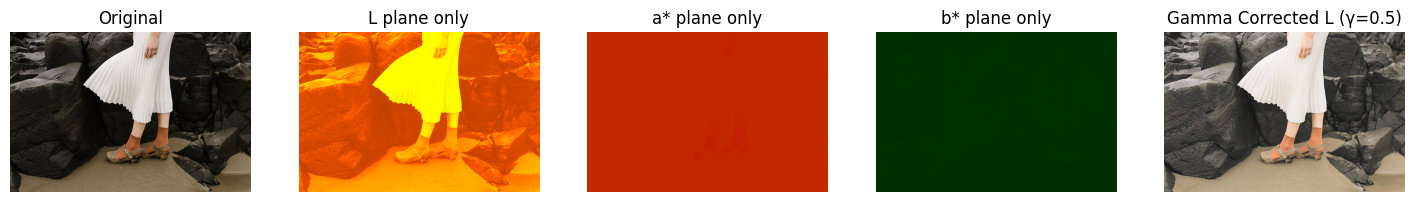

In [36]:
fig, ax = plt.subplots(1,5,figsize=(18,8))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[1].imshow(cv.cvtColor(L_plane, cv.COLOR_LAB2BGR))
ax[1].set_title('L plane only')
ax[2].imshow(cv.cvtColor(a_plane, cv.COLOR_LAB2BGR))
ax[2].set_title('a* plane only')
ax[3].imshow(cv.cvtColor(b_plane, cv.COLOR_LAB2BGR))
ax[3].set_title('b* plane only')
ax[4].imshow(cv.cvtColor(im_gamma, cv.COLOR_BGR2RGB))
ax[4].set_title(f'Gamma Corrected L (γ={gamma})')
for a in ax:
    a.axis('off')
plt.show()

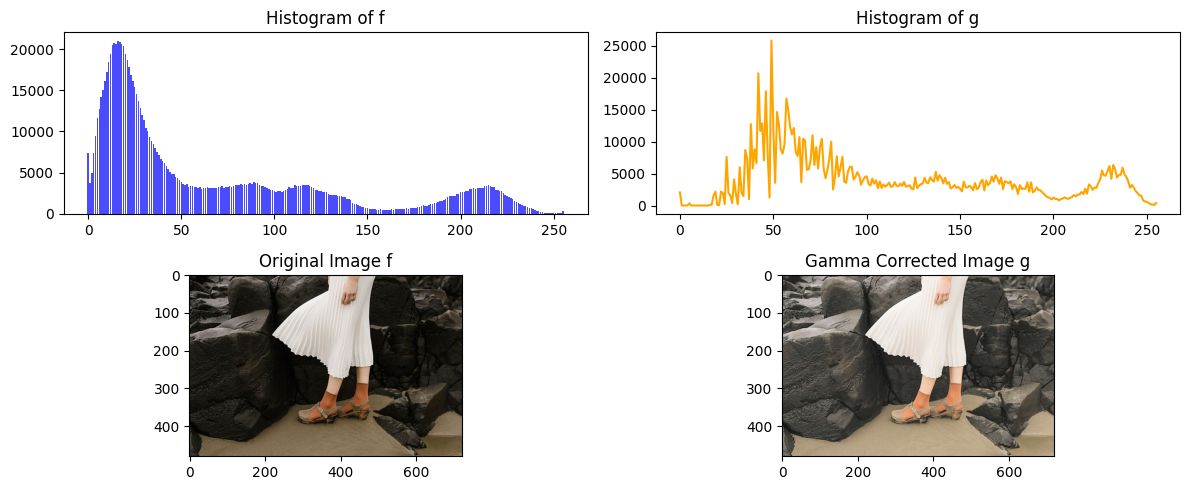

In [45]:
f = cv.cvtColor(im, cv.COLOR_BGR2RGB)          
g = cv.cvtColor(im_gamma, cv.COLOR_BGR2RGB)    

M, N = f.shape[0], f.shape[1]
M

L = 255

hist = np.bincount(f.ravel(), minlength=256)

hist_g = np.bincount(g.ravel(), minlength=256)

fig, ax = plt.subplots(2,2, figsize=(12,5))
ax[0,0].bar(range(256), hist, color='blue', alpha=0.7)
ax[0,0].set_title('Histogram of f')
ax[0,1].plot(range(256), hist_g, color='orange')
ax[0,1].set_title('Histogram of g')
ax[1,0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1,0].set_title('Original Image f')
ax[1,1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1,1].set_title('Gamma Corrected Image g')
plt.tight_layout()
plt.show()

---